# WEEK - 01
## DATASET SETUP

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("screentime.csv")

In [3]:
print(df.shape)

(9712, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [5]:
print(df.head())

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN          Urban  
4     Poor Sleep, Anx

In [6]:
df["Health_Impacts"] = df["Health_Impacts"].fillna("No Health Impact")

In [7]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nMissing percentage:\n", missing_percent[missing_percent > 0])


Missing percentage:
 Series([], dtype: float64)


In [8]:
print(df["Health_Impacts"].unique())

['Poor Sleep, Eye Strain' 'Poor Sleep' 'No Health Impact'
 'Poor Sleep, Anxiety' 'Poor Sleep, Obesity Risk' 'Eye Strain'
 'Obesity Risk' 'Anxiety' 'Poor Sleep, Anxiety, Obesity Risk'
 'Eye Strain, Obesity Risk' 'Eye Strain, Anxiety, Obesity Risk'
 'Anxiety, Obesity Risk' 'Poor Sleep, Eye Strain, Obesity Risk'
 'Poor Sleep, Eye Strain, Anxiety'
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk' 'Eye Strain, Anxiety']


In [9]:
print("\nAfter cleaning:\n", df.isnull().sum())


After cleaning:
 Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64


# WEEK - 02
## Creating Derived Columns 


In [10]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Duplicate rows: 44
After removing duplicates: (9668, 8)


In [11]:
# checking if there any inconsistent data

print(df["Gender"].unique())
print(df["Primary_Device"].unique())
print(df["Urban_or_Rural"].unique())
print(df["Exceeded_Recommended_Limit"].unique())
print(df["Health_Impacts"].unique())

['Male' 'Female']
['Smartphone' 'Laptop' 'TV' 'Tablet']
['Urban' 'Rural']
[ True False]
['Poor Sleep, Eye Strain' 'Poor Sleep' 'No Health Impact'
 'Poor Sleep, Anxiety' 'Poor Sleep, Obesity Risk' 'Eye Strain'
 'Obesity Risk' 'Anxiety' 'Poor Sleep, Anxiety, Obesity Risk'
 'Eye Strain, Obesity Risk' 'Eye Strain, Anxiety, Obesity Risk'
 'Anxiety, Obesity Risk' 'Poor Sleep, Eye Strain, Obesity Risk'
 'Poor Sleep, Eye Strain, Anxiety'
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk' 'Eye Strain, Anxiety']


In [12]:
# Derived Columns
# Age Band using Age column

df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[0, 8, 12, 16, 20],
    labels=['Young Kids', 'Pre-Teens', 'Teenagers', 'Older Teens']
)
print(df["Age_Band"].value_counts())

Age_Band
Teenagers      3543
Pre-Teens      3468
Older Teens    1757
Young Kids      900
Name: count, dtype: int64


In [13]:
# percentage of kids who exceeded limit in each age group

print(df.groupby("Age_Band", observed=True)["Exceeded_Recommended_Limit"].mean()* 100)

Age_Band
Young Kids     75.888889
Pre-Teens      81.978085
Teenagers      90.036692
Older Teens    89.698349
Name: Exceeded_Recommended_Limit, dtype: float64


In [14]:
# Screen Time Category
# Low (0–2 hrs) Moderate (2–4 hrs) High (4–6 hrs) Very High (>6 hrs)

df["Screen_Time_Level"] = pd.cut(
    df["Avg_Daily_Screen_Time_hr"],
    bins=[0, 2, 4, 6, float("inf")],
    labels=["Low", "Moderate", "High", "Very High"],
    include_lowest=True
)
df[["Avg_Daily_Screen_Time_hr", "Screen_Time_Level"]].head()

,Avg_Daily_Screen_Time_hr,Screen_Time_Level
0,3.99,Moderate
1,4.61,High
2,3.73,Moderate
3,1.21,Low
4,5.89,High


In [15]:
# counting of kids in screen time level

df["Screen_Time_Level"].value_counts()

Screen_Time_Level
High         4589
Moderate     2927
Very High    1354
Low           798
Name: count, dtype: int64

In [16]:
# Risk Level categorical column using Exceeded_Recommended_Limit column

df["Risk_Level"] = df["Exceeded_Recommended_Limit"].apply(
    lambda x: "At Risk" if x else "Safe"
)
print(df[["Exceeded_Recommended_Limit", "Risk_Level"]].head())

   Exceeded_Recommended_Limit Risk_Level
0                        True    At Risk
1                        True    At Risk
2                        True    At Risk
3                       False       Safe
4                        True    At Risk


In [17]:
# counting of kids in risk level based

print(df["Risk_Level"].value_counts())

Risk_Level
At Risk    8292
Safe       1376
Name: count, dtype: int64


In [18]:
# Health_Severity derived col using Health_Impacts col

df["Health_Severity"] = df["Health_Impacts"].apply(
    lambda x: "No Impact" if x == "No Health Impact"
    else "Mild" if len(str(x).split(",")) == 1
    else "Moderate" if len(str(x).split(",")) == 2
    else "Severe"
)
print(df[["Health_Impacts", "Health_Severity"]].head())

           Health_Impacts Health_Severity
0  Poor Sleep, Eye Strain        Moderate
1              Poor Sleep            Mild
2              Poor Sleep            Mild
3        No Health Impact       No Impact
4     Poor Sleep, Anxiety        Moderate


In [19]:
# counting of kids in health condition based

print(df["Health_Severity"].value_counts())

Health_Severity
Mild         3545
No Impact    3180
Moderate     2347
Severe        596
Name: count, dtype: int64


In [30]:
# Digital_Balance

df["Digital_Balance"] = df["Educational_to_Recreational_Ratio"].apply(
    lambda x: "Balanced" if x == 1
    else "High Usage" if x < 0.5
    else "Moderate Usage"
)
print(df[["Educational_to_Recreational_Ratio", "Digital_Balance"]].head())

   Educational_to_Recreational_Ratio Digital_Balance
0                               0.42      High Usage
1                               0.30      High Usage
2                               0.32      High Usage
3                               0.39      High Usage
4                               0.49      High Usage


In [31]:
print(df["Digital_Balance"].value_counts())

Digital_Balance
High Usage        8085
Moderate Usage    1583
Name: count, dtype: int64


In [32]:
# creating Screen_Size_Type derived col using primary device col

df["Screen_Size_Type"] = df["Primary_Device"].apply(
    lambda x: "Small Screen" if x.lower() == "smartphone"
    else "Medium Screen" if x.lower() == "tablet"
    else "Large Screen"
)
df[["Primary_Device", "Screen_Size_Type"]].head()

,Primary_Device,Screen_Size_Type
0,Smartphone,Small Screen
1,Laptop,Large Screen
2,TV,Large Screen
3,Laptop,Large Screen
4,Smartphone,Small Screen


In [33]:
# weekday | weekend derived col

df["Day_Type"] = df["Avg_Daily_Screen_Time_hr"].apply(
    lambda x: "Weekend" if x > 3 else "Weekday"
)

df["Day_Type"].value_counts()

Day_Type
Weekend    7950
Weekday    1718
Name: count, dtype: int64

In [34]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Screen_Time_Level,Risk_Level,Health_Severity,Digital_Balance,Screen_Size_Type,Day_Type
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teenagers,Moderate,At Risk,Moderate,High Usage,Small Screen,Weekend
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teens,High,At Risk,Mild,High Usage,Large Screen,Weekend
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Older Teens,Moderate,At Risk,Mild,High Usage,Large Screen,Weekend
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban,Teenagers,Low,Safe,No Impact,High Usage,Large Screen,Weekday
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teens,High,At Risk,Moderate,High Usage,Small Screen,Weekend


## Saving Cleaned Dataset File

In [35]:
df.to_csv("cleaned_screentime_data.csv", index=False)

# WEEK - 03
## UNIVARIATE ANALYSIS & BIVARIATE ANALYSIS

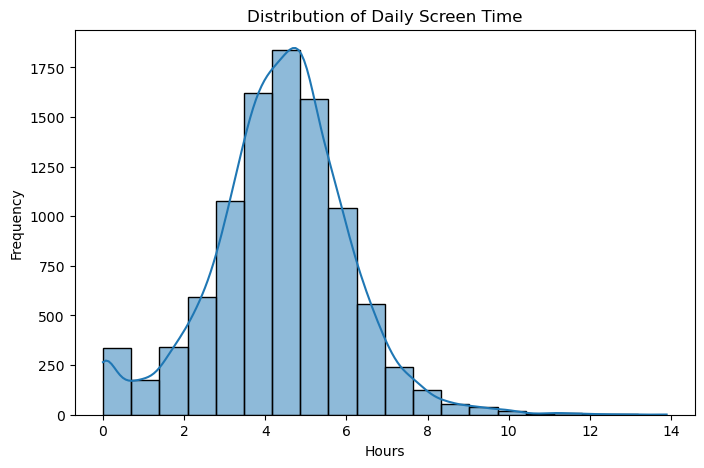

In [36]:
# Screen Time Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=20, kde=True)
plt.title("Distribution of Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

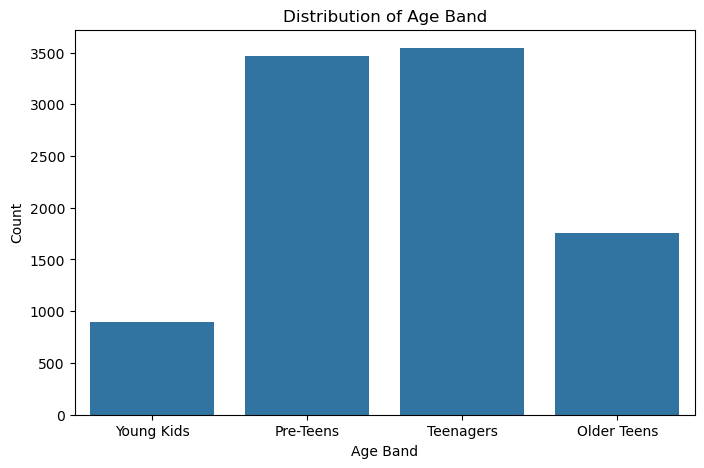

In [37]:
# which age group appears more in dataset

plt.figure(figsize=(8,5))
sns.countplot(x='Age_Band', data=df)
plt.title("Distribution of Age Band")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

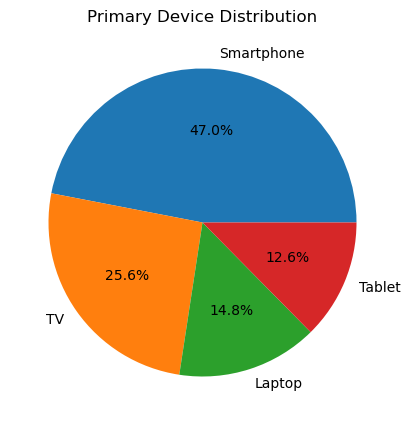

In [38]:
# Distribution of Device usage

plt.figure(figsize=(5,5))
df["Primary_Device"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Primary Device Distribution")
plt.ylabel("")
plt.show()

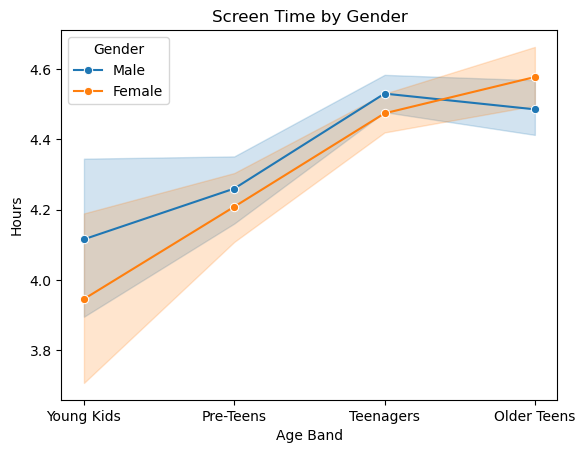

In [39]:
# Compare screentime by gender

sns.lineplot(x="Age_Band", y="Avg_Daily_Screen_Time_hr", hue="Gender", data=df, marker="o")
plt.title("Screen Time by Gender")
plt.xlabel("Age Band")
plt.ylabel("Hours")
plt.show()

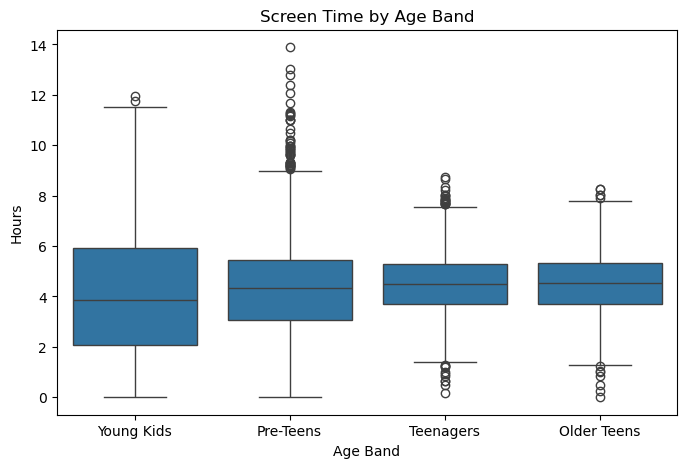

In [40]:
# Compare screentime by age band

plt.figure(figsize=(8,5))
sns.boxplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Hours")
plt.show()

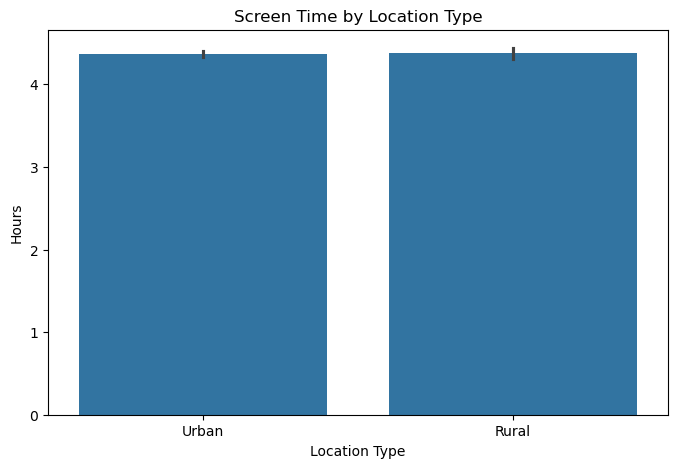

In [41]:
# Screen time by location type

plt.figure(figsize=(8,5))
sns.barplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Hours")
plt.show()

# WEEK - 04
## DEVICE / ACTIVITY ANALYSIS

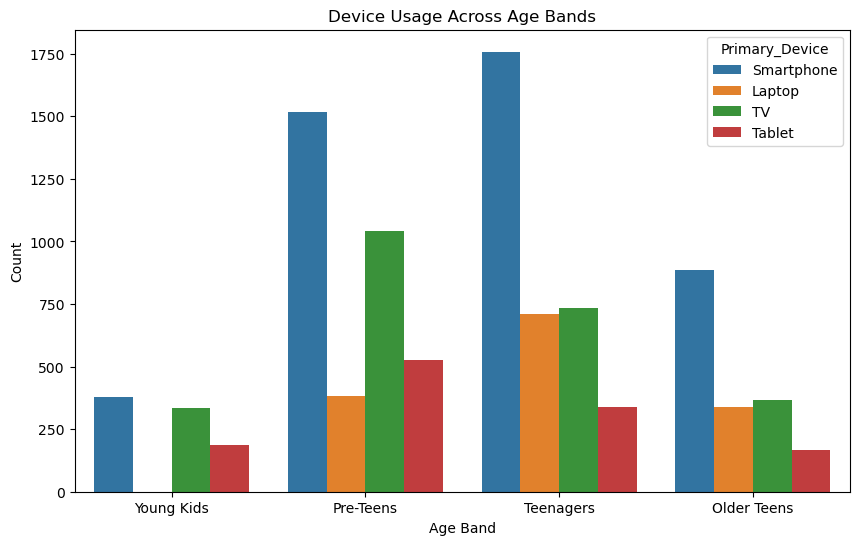

In [42]:
# Device usage across age bands

plt.figure(figsize=(10,6))
sns.countplot(x="Age_Band", hue="Primary_Device", data=df)
plt.title("Device Usage Across Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

### OBSERVATION :
#### - Teenagers show higher usage of personal devices.
#### - Younger kids depend more on shared or limited devices.

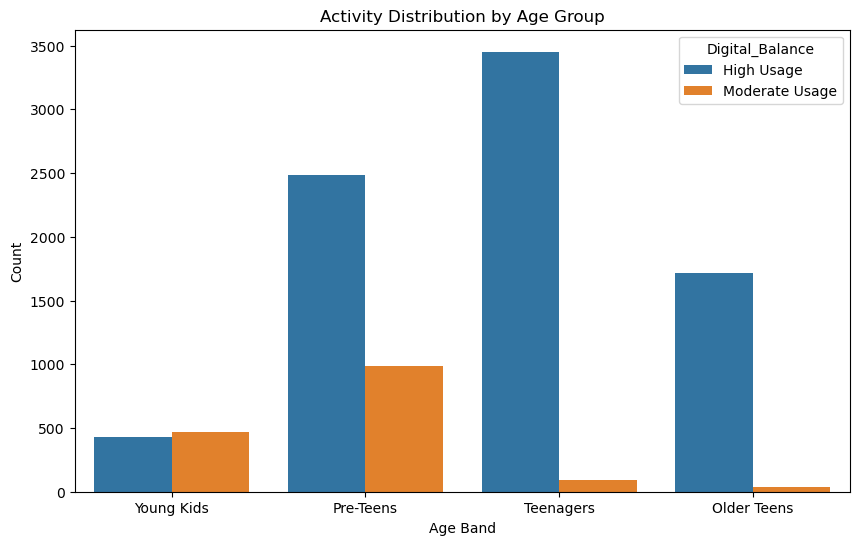

In [43]:
# Activity (digital_balance) usage by Age Band

plt.figure(figsize=(10,6))
sns.countplot(x="Age_Band", hue="Digital_Balance", data=df)
plt.title("Activity Distribution by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

### OBSERVATION :
#### - Teenagers have more balanced or mixed digital activities.
#### - Younger groups show less diverse activity patterns.

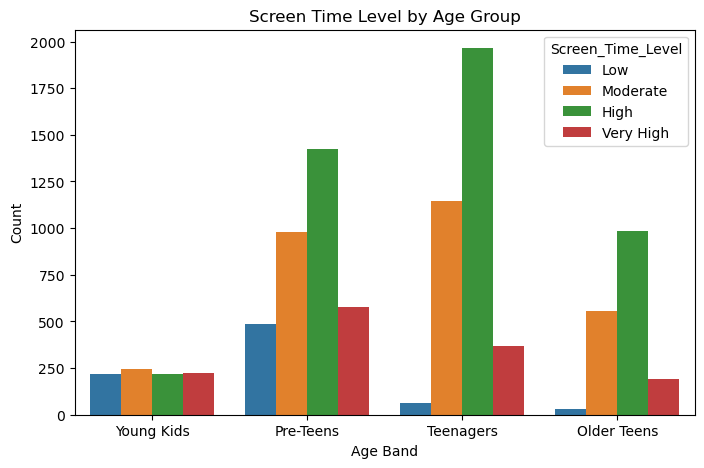

In [44]:
# Screen Time Level by Age

plt.figure(figsize=(8,5))
sns.countplot(x="Age_Band", hue="Screen_Time_Level", data=df)
plt.title("Screen Time Level by Age Group")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()

### OBSERVATION :
#### - Teenagers fall more in high screen time category.
#### - Young kids mostly stay in low to moderate usage.

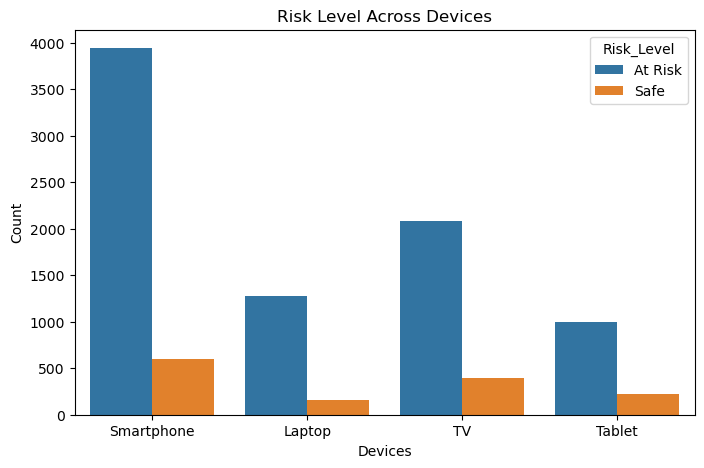

In [45]:
# Risk Level by Device

plt.figure(figsize=(8,5))
sns.countplot(x="Primary_Device", hue="Risk_Level", data=df)
plt.title("Risk Level Across Devices")
plt.xlabel("Devices")
plt.ylabel("Count")
plt.show()

### OBSERVATION :
#### - High risk is more associated with mobile device usage.
#### - Other devices show comparatively lower risk levels.

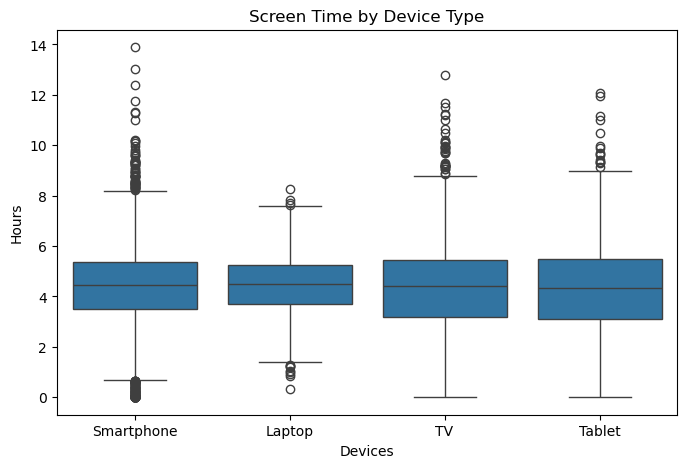

In [46]:
# Screen Time by Device Type

plt.figure(figsize=(8,5))
sns.boxplot(
    x="Primary_Device",
    y="Avg_Daily_Screen_Time_hr",
    data=df
)
plt.title("Screen Time by Device Type")
plt.xlabel("Devices")
plt.ylabel("Hours")
plt.show()

### OBSERVATION :
#### - Mobile users have higher average screen time.
#### - Some users show extreme (very high) usage patterns.

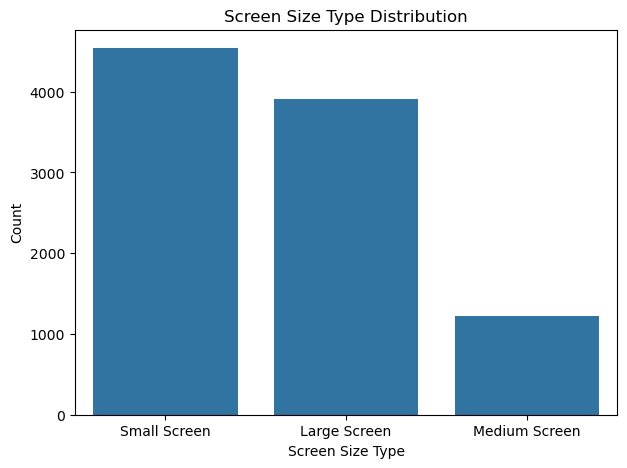

In [47]:
# Screen Size Type Distribution

plt.figure(figsize=(7,5))
sns.countplot(x="Screen_Size_Type", data=df)
plt.title("Screen Size Type Distribution")
plt.xlabel("Screen Size Type")
plt.ylabel("Count")
plt.show()

### OBSERVATION :
#### - Medium or small screen devices are most commonly used.
#### - Large screen usage is less frequent.

### WEEKDAY / WEEKEND ANALYSIS

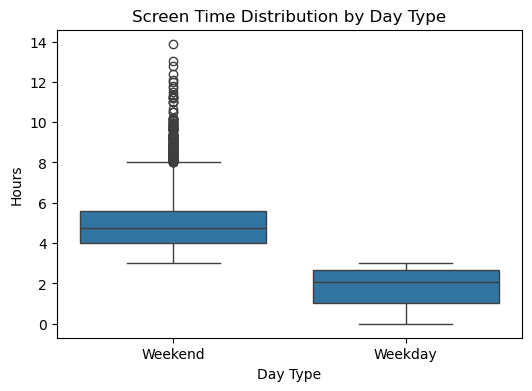

In [48]:
# screen time by Day type

plt.figure(figsize=(6,4))
sns.boxplot(x="Day_Type",
            y="Avg_Daily_Screen_Time_hr",
            data=df)
plt.title("Screen Time Distribution by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Hours")
plt.show()

### OBSERVATION :
#### - Screen time is higher on weekends.
#### - Weekdays show more controlled usage.

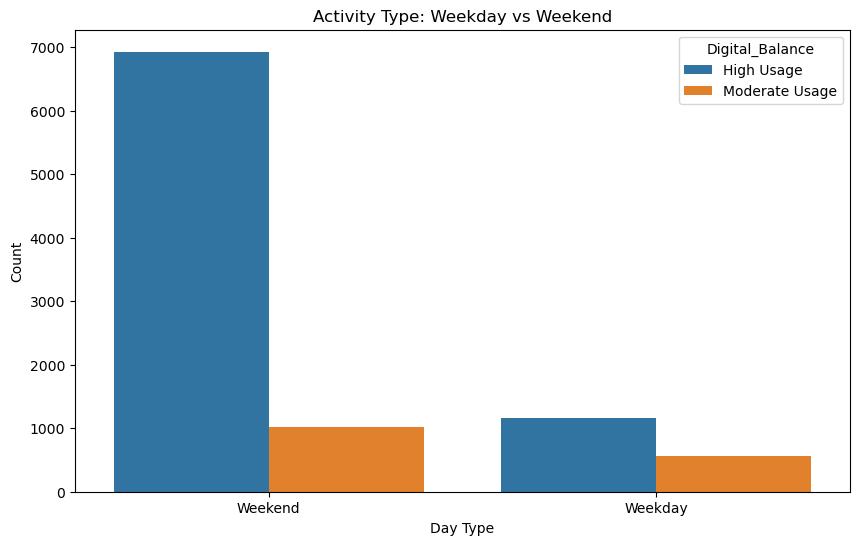

In [49]:
# Activity by Day type

plt.figure(figsize=(10,6))
sns.countplot(x="Day_Type", hue="Digital_Balance", data=df)
plt.title("Activity Type: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Count")
plt.show()

### OBSERVATION :
#### - Weekend activities are more entertainment-based.
#### - Weekday usage is more structured or limited.

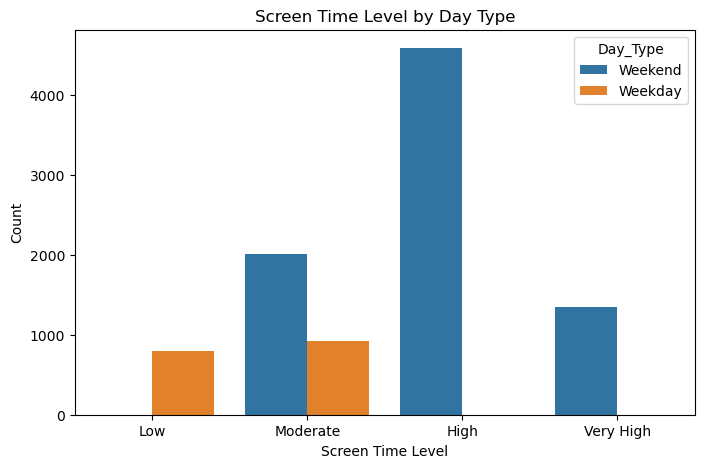

In [50]:
# Screen time level by day type

plt.figure(figsize=(8,5))
sns.countplot(
    x="Screen_Time_Level",
    hue="Day_Type",
    data=df
)
plt.title("Screen Time Level by Day Type")
plt.xlabel("Screen Time Level")
plt.ylabel("Count")
plt.show()

### OBSERVATION :
#### - High screen time is more common on weekends.
#### - Weekdays mostly fall under moderate usage.

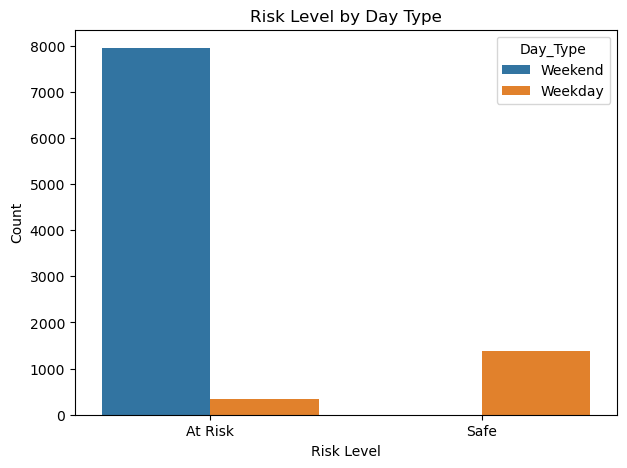

In [51]:
# Risk Level by day type

plt.figure(figsize=(7,5))
sns.countplot(
    x="Risk_Level",
    hue="Day_Type",
    data=df
)
plt.title("Risk Level by Day Type")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

### OBSERVATION :
#### - Risk levels slightly increase during weekends.
#### - Weekdays show relatively lower risk exposure.

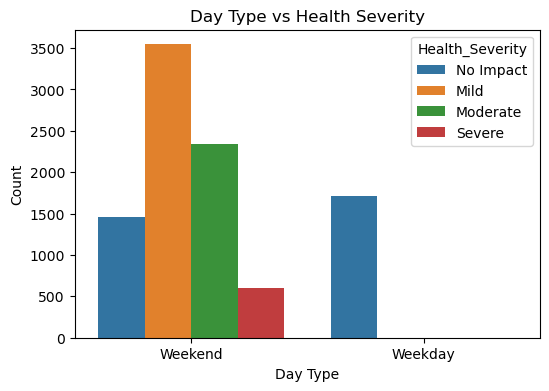

In [52]:
# Health severity by day type

plt.figure(figsize=(6,4))
sns.countplot(x="Day_Type",
              hue="Health_Severity",
              data=df,
              hue_order=["No Impact","Mild","Moderate","Severe"])
plt.title("Day Type vs Health Severity")
plt.xlabel("Day Type")
plt.ylabel("Count")
plt.show()

### OBSERVATION :
#### - Higher health impact is seen more on weekends.
#### - Weekdays show No Impact cases.

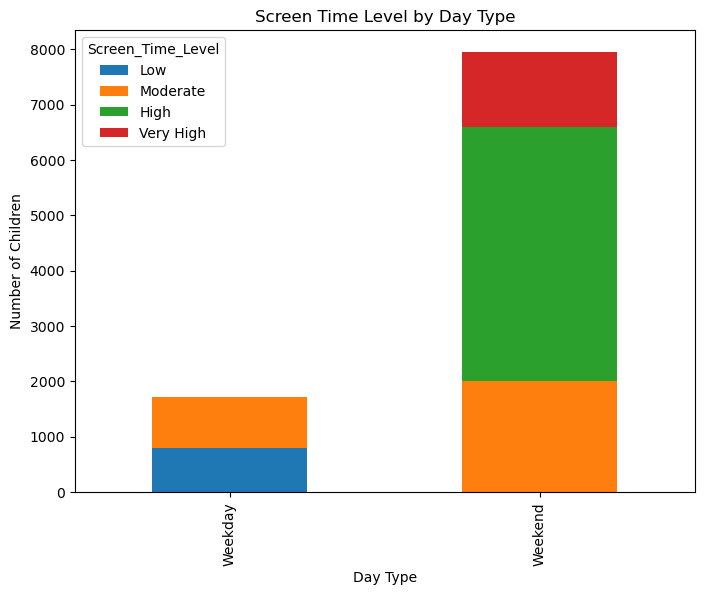

In [53]:
# Compare weekday vs weekend screen time.

day_screen = pd.crosstab(df["Day_Type"], df["Screen_Time_Level"])
day_screen.plot(kind="bar", stacked=True, figsize=(8,6))
plt.title("Screen Time Level by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Number of Children")
plt.show()

### OBSERVATION :
#### - Weekend has more high screen time users.
#### - Weekday users are mostly in low/moderate categories.

# WEEK - 05
## COHORT AND SEGMENT ANALYSIS

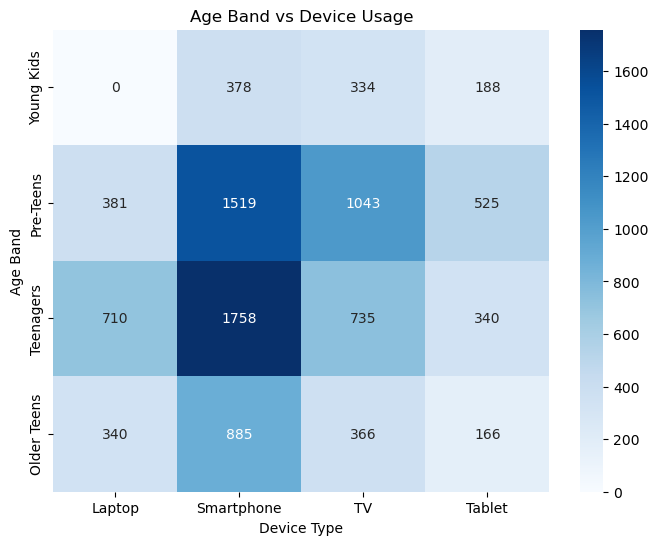

In [54]:
# which age group uses which device the most.

cohort_device = pd.crosstab(df["Age_Band"], df["Primary_Device"])
plt.figure(figsize=(8,6))
sns.heatmap(cohort_device, annot=True, cmap="Blues", fmt="d")
plt.title("Age Band vs Device Usage")
plt.xlabel("Device Type")
plt.ylabel("Age Band")
plt.show()

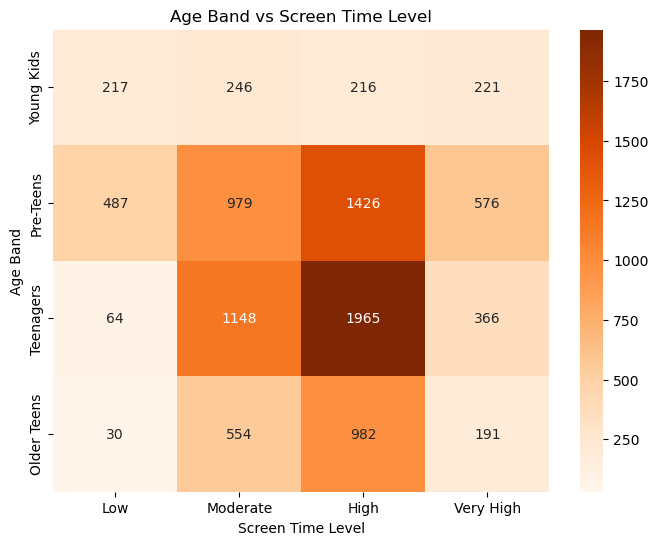

In [55]:
# Identify which age group has higher screen time.

age_screen = pd.crosstab(df["Age_Band"], df["Screen_Time_Level"])
plt.figure(figsize=(8,6))
sns.heatmap(age_screen, annot=True, cmap="Oranges", fmt="d")
plt.title("Age Band vs Screen Time Level")
plt.xlabel("Screen Time Level")
plt.ylabel("Age Band")
plt.show()

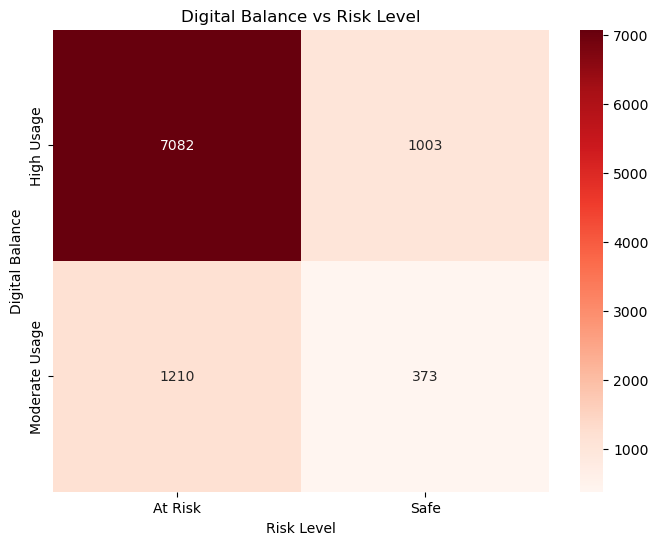

In [56]:
# Check if recreational usage leads to higher risk.

balance_risk = pd.crosstab(df["Digital_Balance"], df["Risk_Level"])
plt.figure(figsize=(8,6))
sns.heatmap(balance_risk, annot=True, cmap="Reds", fmt="d")
plt.title("Digital Balance vs Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Digital Balance")
plt.show()

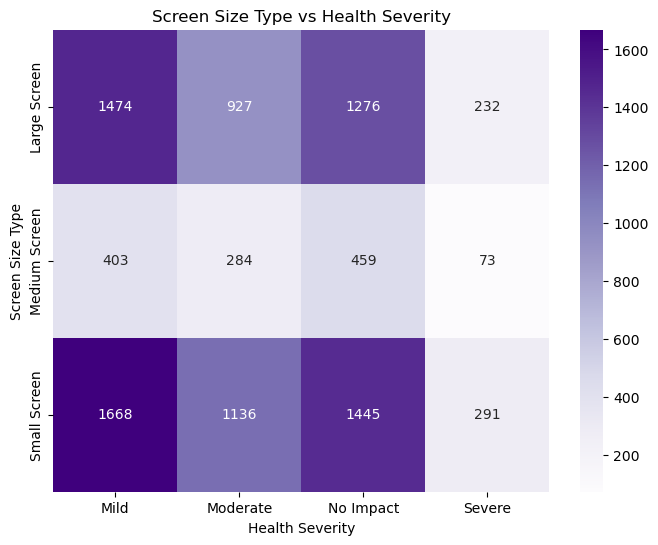

In [57]:
# Check if small screens affect health more.

screen_health = pd.crosstab(df["Screen_Size_Type"], df["Health_Severity"])
plt.figure(figsize=(8,6))
sns.heatmap(screen_health, annot=True, cmap="Purples", fmt="d")
plt.title("Screen Size Type vs Health Severity")
plt.xlabel("Health Severity")
plt.ylabel("Screen Size Type")
plt.show()

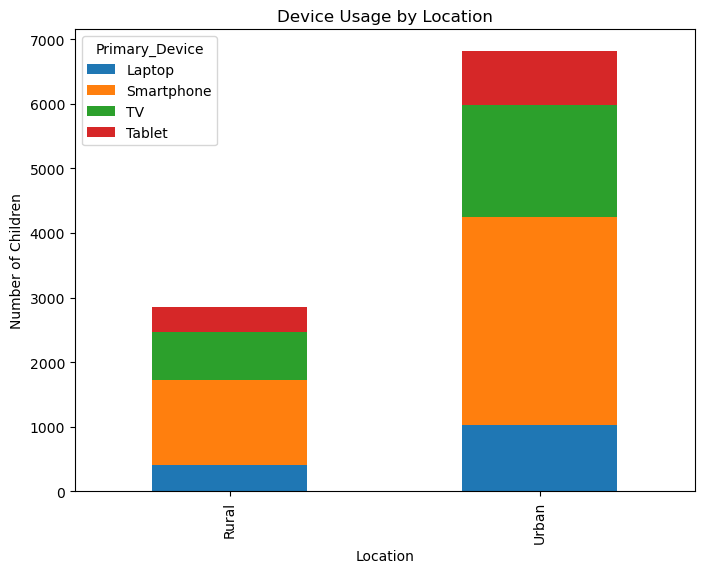

In [58]:
# Compare device usage by location.

location_device = pd.crosstab(df["Urban_or_Rural"], df["Primary_Device"])
location_device.plot(kind="bar", stacked=True, figsize=(8,6))
plt.title("Device Usage by Location")
plt.xlabel("Location")
plt.ylabel("Number of Children")
plt.show()

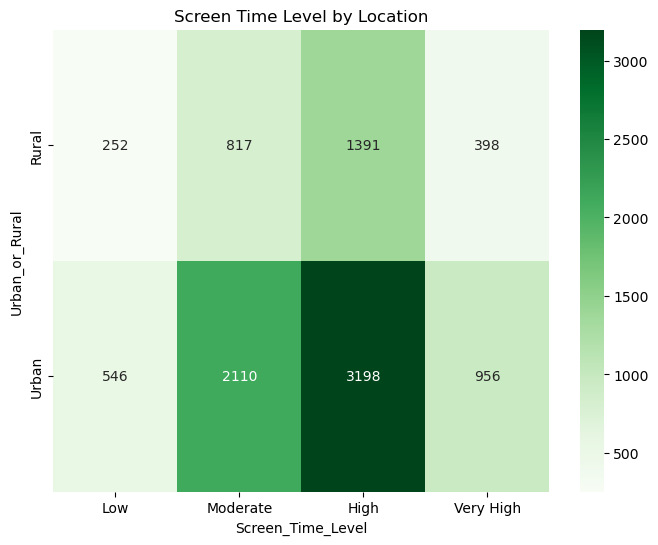

In [59]:
# Compare screen exposure by location.

location_screen = pd.crosstab(df["Urban_or_Rural"], df["Screen_Time_Level"])
plt.figure(figsize=(8,6))
sns.heatmap(location_screen, annot=True, cmap="Greens", fmt="d")
plt.title("Screen Time Level by Location")
plt.show()

### Top Cohort Insights
#### - Teenagers → Highest usage
#### - Mobile users → Dominant device
#### - Teenagers + Mobile → Top cohort
#### - High screen time → Teenagers
#### - Recreational usage → High risk
#### - Balanced usage → Low risk
#### - Small screens → Health issues
#### - Urban children → More usage
#### - Rural children → Less usage
#### - High usage → High risk

# WEEK - 06
## HABIT PATTERN ANALYSIS

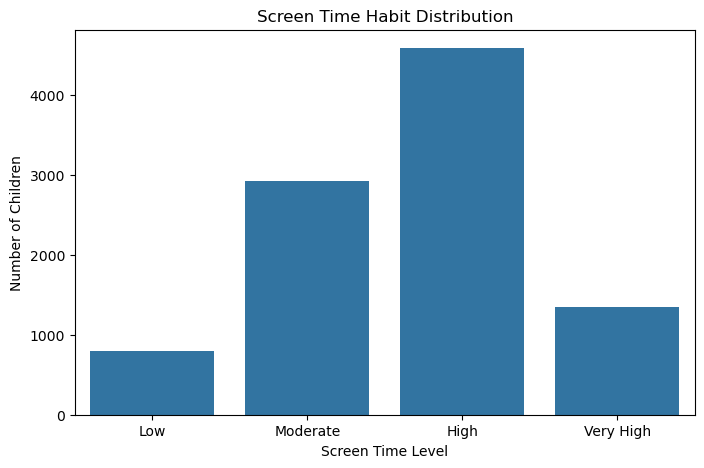

In [60]:
plt.figure(figsize=(8,5))
sns.countplot(x="Screen_Time_Level", data=df)
plt.title("Screen Time Habit Distribution")
plt.xlabel("Screen Time Level")
plt.ylabel("Number of Children")
plt.show()

### INSIGHTS
#### - Most children fall under moderate screen time.
#### - A smaller group shows very high screen usage.

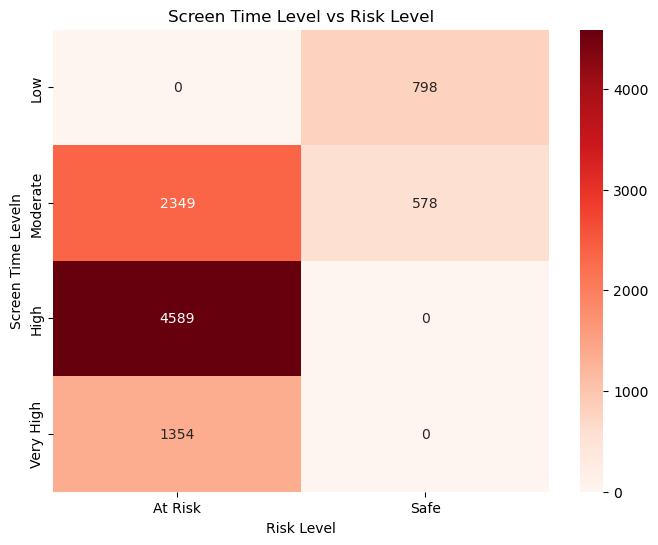

In [61]:
# Identify risk behavior patterns

risk_pattern = pd.crosstab(df["Screen_Time_Level"], df["Risk_Level"])
plt.figure(figsize=(8,6))
sns.heatmap(risk_pattern, annot=True, cmap="Reds", fmt="d")
plt.title("Screen Time Level vs Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Screen Time Leveln")
plt.show()

### INSIGHTS
#### - Higher screen time is clearly linked with higher risk levels.
#### - Low screen time mostly shows low risk.

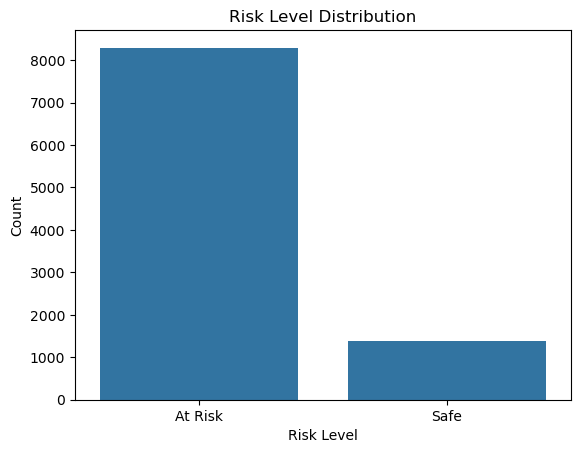

In [62]:
sns.countplot(x="Risk_Level", data=df)
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

### INSIGHTS
#### - Most children fall under low to moderate risk.
#### - Only a smaller group is in high risk category.

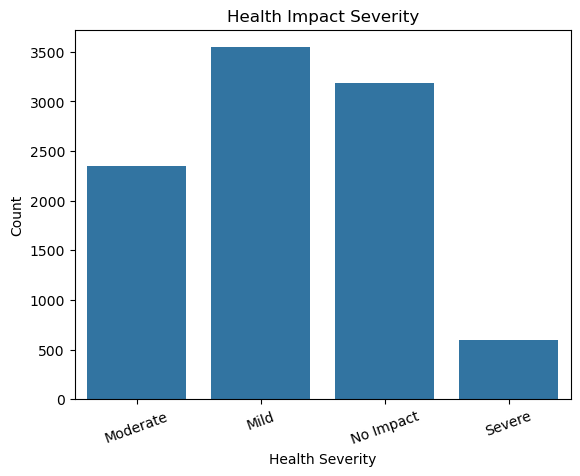

In [63]:
sns.countplot(x="Health_Severity", data=df)
plt.title("Health Impact Severity")
plt.xticks(rotation=20)
plt.xlabel("Health Severity")
plt.ylabel("Count")
plt.show()

### INSIGHTS
#### - Most children show no or mild health impact.
#### - Severe health issues are less common.

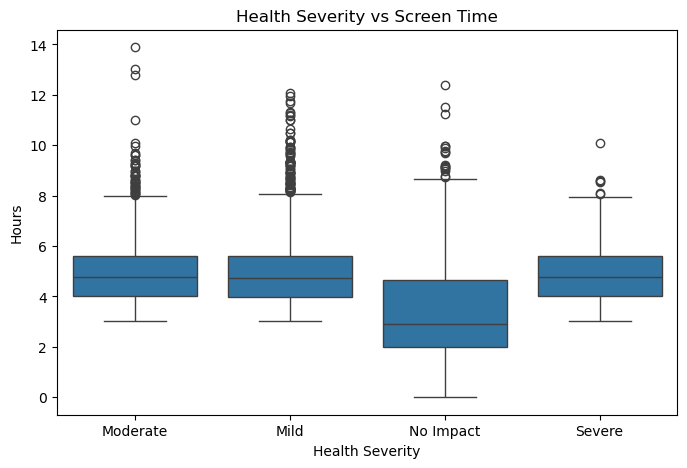

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Health_Severity",
    y="Avg_Daily_Screen_Time_hr",
    data=df
)
plt.title("Health Severity vs Screen Time")
plt.xlabel("Health Severity")
plt.ylabel("Hours")
plt.show()

### INSIGHTS
#### - Children with higher screen time show more health issues.
#### - Lower screen time is linked with fewer health problems.

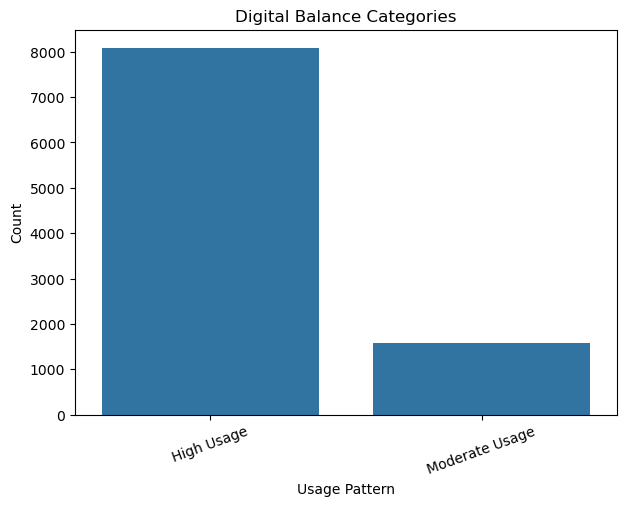

In [65]:
# learning vs entertainment balance

plt.figure(figsize=(7,5))
sns.countplot(x="Digital_Balance", data=df)
plt.title("Digital Balance Categories")
plt.xlabel("Usage Pattern")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

### INSIGHTS
#### - Many children follow a mixed or balanced usage pattern.
#### - Some children still show more recreational usage.

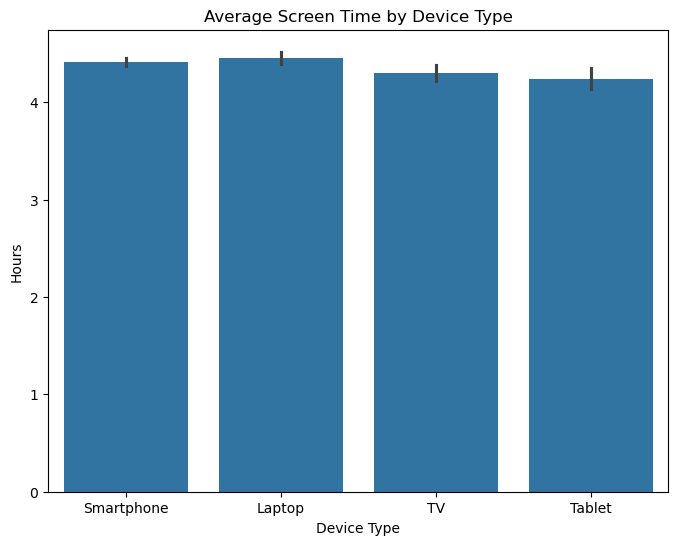

In [66]:
# checking which device drives higher screen time

plt.figure(figsize=(8,6))
sns.barplot(x="Primary_Device", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Average Screen Time by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Hours")
plt.show()

### INSIGHTS
#### - Mobile devices have the highest average screen time.
#### - Other devices show comparatively lower usage.

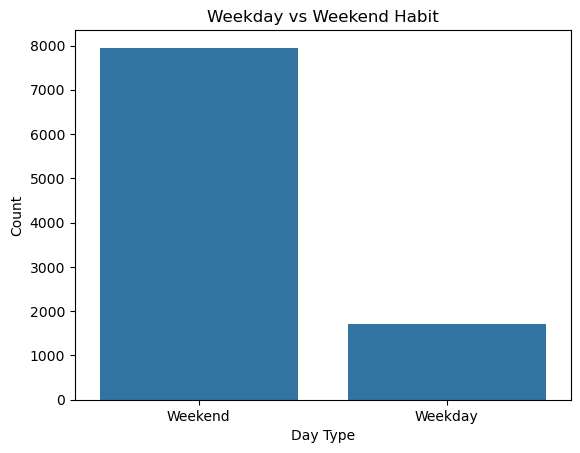

In [67]:
# DAY TYPE HABIT

sns.countplot(x="Day_Type", data=df)
plt.title("Weekday vs Weekend Habit")
plt.xlabel("Day Type")
plt.ylabel("Count")
plt.show()

### INSIGHTS
#### - Weekend usage is slightly higher than weekdays.
#### - Weekdays show more controlled screen habits.

### SEGMENT INSIGHTS
#### - High screen time leads to higher risk and health impact
#### - Mobile usage drives most screen exposure
#### - Recreational habits increase risk levels
#### - Weekends contribute to increased screen usage
#### - Balanced usage helps reduce risk and health issues